In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import sklearn.metrics as skm
from scipy.stats import ks_2samp
import math
import shap
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from scipy.stats import spearmanr
import shutil
from itertools import chain

# silence warnings
import warnings
warnings.filterwarnings('ignore')

# binning
try:
    from optbinning import OptimalBinning
except:
    ! pip install optbinning
    from optbinning import OptimalBinning

#### Functions

In [2]:
# get pmt hx
def make_auto_pmt_hx_df(ser_row):
    # replace nan with None
    ser_row = ser_row.str.replace('nan', 'None')
    # convert to lists
    ser_row = ser_row.apply(eval)
    # make into dictionary
    dict_ser_row = dict(ser_row)
    # make df
    try:
        df_tmp = pd.DataFrame(dict_ser_row)
    except ValueError:
        dict_output = {
            # overall
            'flt_mean_months_to_first_bad': np.nan,
            # open
            'flt_payment_open': np.nan,
            'int_n_months_open': np.nan,
            'list_pmt_hx_open': np.nan,
            'flt_wtd_avg_open': np.nan,
            'flt_avg_open': np.nan,
            'int_30dpd_open': np.nan,
            'int_60dpd_open': np.nan,
            'int_90dpd_open': np.nan,
            'int_bad_3mo_open': np.nan,
            'int_bad_6mo_open': np.nan,
            'int_bad_3mo_open_end': np.nan,
            'int_bad_6mo_open_end': np.nan,
            # closed
            'flt_payment_closed': np.nan,
            'int_n_months_closed': np.nan,
            'list_pmt_hx_closed': np.nan,
            'flt_wtd_avg_closed': np.nan,
            'flt_avg_closed': np.nan,
            'int_30dpd_closed': np.nan,
            'int_60dpd_closed': np.nan,
            'int_90dpd_closed': np.nan,
            'int_bad_3mo_closed': np.nan,
            'int_bad_6mo_closed': np.nan,
            'int_bad_3mo_closed_end': np.nan,
            'int_bad_6mo_closed_end': np.nan,
        }
        # return
        return dict_output
    
    # get only auto
    df_tmp = df_tmp[df_tmp['auto__tu_pmthx'] == 1].copy()
    
    # columns
    list_cols = [
        'str_dtm_opened__tu_pmthx',
        'str_dtm_closed__tu_pmthx',
        'str_dtm_most_recent_pmt__tu_pmthx',
    ]
    # make dtm
    for col in list_cols:
        # make str_dtm_opened__tu_pmthx a datetime
        df_tmp[col] = pd.to_datetime(df_tmp[col])
    # sort
    df_tmp.sort_values(by='str_dtm_opened__tu_pmthx', ascending=False, inplace=True)
    
    # tag open
    df_tmp['tag_open'] = df_tmp['str_dtm_closed__tu_pmthx'].apply(
        lambda x: 1 if pd.isnull(x) else 0,
    )
    
    # fillna
    df_tmp['str_pmt_hx__tu_pmthx'] = df_tmp['str_pmt_hx__tu_pmthx'].fillna('')
    
    # remove Y from payment hx
    df_tmp['str_pmt_hx__tu_pmthx'] = df_tmp['str_pmt_hx__tu_pmthx'].apply(
        lambda x: [str_val for str_val in list(x) if str_val != 'Y'],
    )
    
    # get n payments
    df_tmp['n_months'] = df_tmp['str_pmt_hx__tu_pmthx'].apply(
        lambda x: len(x),
    )
    
    # convert str_pmt_hx__tu_pmthx to lists of 1 and 0
    df_tmp['str_pmt_hx__tu_pmthx'] = df_tmp['str_pmt_hx__tu_pmthx'].apply(
        lambda x: [1 if str_val in ['1','E'] else 0 for str_val in list(x)],
    )
    
    # reverse the order of the lists
    df_tmp['str_pmt_hx__tu_pmthx'] = df_tmp['str_pmt_hx__tu_pmthx'].apply(
        lambda x: x[::-1] if isinstance(x, list) else x,
    )
    
    # first month of bad event
    df_tmp['month_first_bad'] = df_tmp['str_pmt_hx__tu_pmthx'].apply(
         lambda x: pd.Series(list(x))[pd.Series(list(x)) != 1].index.min()+1,
    )
    # months to first bad
    df_tmp['months_to_first_bad'] = df_tmp['month_first_bad'].fillna(df_tmp['n_months'])
    # make it a proportion
    df_tmp['months_to_first_bad'] = df_tmp['months_to_first_bad'] / df_tmp['n_months']
    
    # get mean proportion months to first bad overall open and closed - all
    flt_mean_months_to_first_bad = df_tmp['months_to_first_bad'].mean()
    
    # get mean proportion months to first bad overall open and closed - all
    flt_mean_months_to_first_bad = df_tmp['months_to_first_bad'].mean()
    # logic if there is no payment history
    if pd.isnull(flt_mean_months_to_first_bad):
        flt_mean_months_to_first_bad = 0 # lower is worse it means you have early delinquency
    else:
        pass
    
    # get df open
    df_tmp_open = df_tmp[df_tmp['tag_open'] == 1].copy()
    int_nrows = df_tmp_open.shape[0]
    if int_nrows > 0:
        # get mayment
        flt_payment_open = df_tmp_open['flt_payment__tu_pmthx'].iloc[0]
        # get n months
        int_n_months_open = df_tmp_open['n_months'].iloc[0]
        # get the most recent open pmt hx
        list_pmt_hx_open = df_tmp_open['str_pmt_hx__tu_pmthx'].iloc[0]
        # get weighted average
        list_weights = list(range(1, len(list_pmt_hx_open)+1))
        try:
            flt_wtd_avg_open = np.average(list_pmt_hx_open, weights=list_weights)
        except ZeroDivisionError:
            flt_wtd_avg_open = np.nan # lower is worse
        # get normal average
        flt_avg_open = np.mean(list_pmt_hx_open)
        # get DPD
        int_30dpd_open = df_tmp_open['flt_30_dpd__tu_pmthx'].iloc[0]
        int_60dpd_open = df_tmp_open['flt_60_dpd__tu_pmthx'].iloc[0]
        int_90dpd_open = df_tmp_open['flt_90_dpd__tu_pmthx'].iloc[0]
        
        # bad tags
        int_len_list_pmt_hx_open = len(list_pmt_hx_open)
        
        # if they dont have 3 months on file
        if int_len_list_pmt_hx_open < 3:
            int_bad_3mo_open = 1
        elif (int_len_list_pmt_hx_open >= 3) and (np.sum(list_pmt_hx_open[:3]) < 3):
            int_bad_3mo_open = 1
        else:
            int_bad_3mo_open = 0
        
        # if they dont have 6 months on file
        if int_len_list_pmt_hx_open < 3:
            int_bad_6mo_open = 1
        elif (int_len_list_pmt_hx_open >= 6) and (np.sum(list_pmt_hx_open[:6]) < 6):
            int_bad_6mo_open = 1
        else:
            int_bad_6mo_open = 0
        
        # if they dont have 3 months on file
        if int_len_list_pmt_hx_open < 3:
            int_bad_3mo_open_end = 1
        elif (int_len_list_pmt_hx_open >= 3) and (np.sum(list_pmt_hx_open[-3:]) < 3):
            int_bad_3mo_open_end = 1
        else:
            int_bad_3mo_open_end = 0
        
        # if they dont have 6 months on file
        if int_len_list_pmt_hx_open < 3:
            int_bad_6mo_open_end = 1
        elif (int_len_list_pmt_hx_open >= 6) and (np.sum(list_pmt_hx_open[-6:]) < 6):
            int_bad_6mo_open_end = 1
        else:
            int_bad_6mo_open_end = 0
    else:
        flt_payment_open = np.nan
        int_n_months_open = np.nan
        list_pmt_hx_open = np.nan
        flt_wtd_avg_open = np.nan
        flt_avg_open = np.nan
        int_30dpd_open = np.nan
        int_60dpd_open = np.nan
        int_90dpd_open = np.nan
        int_bad_3mo_open = np.nan
        int_bad_6mo_open = np.nan
        int_bad_3mo_open_end = np.nan
        int_bad_6mo_open_end = np.nan
    
    # get df closed
    df_tmp_closed = df_tmp[df_tmp['tag_open'] == 0].copy()
    int_nrows = df_tmp_closed.shape[0]
    if int_nrows > 0:
        # get mayment
        flt_payment_closed = df_tmp_closed['flt_payment__tu_pmthx'].iloc[0]
        # get n months
        int_n_months_closed = df_tmp_closed['n_months'].iloc[0]
        # get the most recent open pmt hx
        list_pmt_hx_closed = df_tmp_closed['str_pmt_hx__tu_pmthx'].iloc[0]
        # get weighted average
        list_weights = list(range(1, len(list_pmt_hx_closed)+1))
        try:
            flt_wtd_avg_closed = np.average(list_pmt_hx_closed, weights=list_weights)
        except ZeroDivisionError:
            flt_wtd_avg_closed = np.nan
        # get normal average
        flt_avg_closed = np.mean(list_pmt_hx_closed)
        # get DPD
        int_30dpd_closed = df_tmp_closed['flt_30_dpd__tu_pmthx'].iloc[0]
        int_60dpd_closed = df_tmp_closed['flt_60_dpd__tu_pmthx'].iloc[0]
        int_90dpd_closed = df_tmp_closed['flt_90_dpd__tu_pmthx'].iloc[0]
        
        # bad tags
        int_len_list_pmt_hx_closed = len(list_pmt_hx_closed)
        
        # if they dont have 3 months on file
        if int_len_list_pmt_hx_closed < 3:
            int_bad_3mo_closed = 1
        elif (int_len_list_pmt_hx_closed >= 3) and (np.sum(list_pmt_hx_closed[:3]) < 3):
            int_bad_3mo_closed = 1
        else:
            int_bad_3mo_closed = 0
        
        # if they dont have 6 months on file
        if int_len_list_pmt_hx_closed < 3:
            int_bad_6mo_closed = 1
        elif (int_len_list_pmt_hx_closed >= 6) and (np.sum(list_pmt_hx_closed[:6]) < 6):
            int_bad_6mo_closed = 1
        else:
            int_bad_6mo_closed = 0
            
        # if they dont have 3 months on file
        if int_len_list_pmt_hx_closed < 3:
            int_bad_3mo_closed_end = 1
        elif (int_len_list_pmt_hx_closed >= 3) and (np.sum(list_pmt_hx_closed[-3:]) < 3):
            int_bad_3mo_closed_end = 1
        else:
            int_bad_3mo_closed_end = 0
        
        # if they dont have 6 months on file
        if int_len_list_pmt_hx_closed < 3:
            int_bad_6mo_closed_end = 1
        elif (int_len_list_pmt_hx_closed >= 6) and (np.sum(list_pmt_hx_closed[-6:]) < 6):
            int_bad_6mo_closed_end = 1
        else:
            int_bad_6mo_closed_end = 0
    else:
        flt_payment_closed = np.nan
        int_n_months_closed = np.nan
        list_pmt_hx_closed = np.nan
        flt_wtd_avg_closed = np.nan
        flt_avg_closed = np.nan
        int_30dpd_closed = np.nan
        int_60dpd_closed = np.nan
        int_90dpd_closed = np.nan
        int_bad_3mo_closed = np.nan
        int_bad_6mo_closed = np.nan
        int_bad_3mo_closed_end = np.nan
        int_bad_6mo_closed_end = np.nan
    
    # dict output
    dict_output = {
        # overall
        'flt_mean_months_to_first_bad': flt_mean_months_to_first_bad,
        # open
        'flt_payment_open': flt_payment_open,
        'int_n_months_open': int_n_months_open,
        'list_pmt_hx_open': list_pmt_hx_open,
        'flt_wtd_avg_open': flt_wtd_avg_open,
        'flt_avg_open': flt_avg_open,
        'int_30dpd_open': int_30dpd_open,
        'int_60dpd_open': int_60dpd_open,
        'int_90dpd_open': int_90dpd_open,
        'int_bad_3mo_open': int_bad_3mo_open,
        'int_bad_6mo_open': int_bad_6mo_open,
        'int_bad_3mo_open_end': int_bad_3mo_closed_end,
        'int_bad_6mo_open_end': int_bad_6mo_closed_end,
        # closed
        'flt_payment_closed': flt_payment_closed,
        'int_n_months_closed': int_n_months_closed,
        'list_pmt_hx_closed': list_pmt_hx_closed,
        'flt_wtd_avg_closed': flt_wtd_avg_closed,
        'flt_avg_closed': flt_avg_closed,
        'int_30dpd_closed': int_30dpd_closed,
        'int_60dpd_closed': int_60dpd_closed,
        'int_90dpd_closed': int_90dpd_closed,
        'int_bad_3mo_closed': int_bad_3mo_closed,
        'int_bad_6mo_closed': int_bad_6mo_closed,
        'int_bad_3mo_closed_end': int_bad_3mo_closed_end,
        'int_bad_6mo_closed_end': int_bad_6mo_closed_end,
    }
    
    # return
    return dict_output

In [3]:
def get_most_positive_and_most_negative_features(ser_row, dict_coef):
    list_dict_row =  []
    for str_col, flt_coef in dict_coef.items():
        flt_contribution = ser_row[str_col] * flt_coef
        dict_row = {
            'feature': str_col,
            'contribution': flt_contribution,
        }
        list_dict_row.append(dict_row)
    df_tmp = pd.DataFrame(list_dict_row)
    df_tmp.sort_values(by='contribution', ascending=True, inplace=True)
    # best
    list_most_negative = df_tmp['feature'].iloc[:5]
    list_most_negative = [f'{col.split("_binned")[0]}' for col in list_most_negative]
    # worst
    list_most_positive = df_tmp['feature'].iloc[-5:]
    list_most_positive = [f'{col.split("_binned")[0]}' for col in list_most_positive]
    # reverse
    list_most_positive = list_most_positive[::-1]
    # make dictionary
    dict_output = {
        'most_negative': list_most_negative,
        'most_positive': list_most_positive,
    }
    # return
    return dict_output

In [4]:
def map_ltv_range_to_lgd_bin(flt_ltv, dict_bins_ltv):
    for flt_threshold, flt_val in dict_bins_ltv.items():
        if flt_ltv <= flt_threshold:
            return flt_val
    # else
    return np.max(list(dict_bins_ltv.values()))

In [5]:
def get_tier(flt_ecnl, dict_tiers):
    if flt_ecnl <= dict_tiers['A1']:
        return 'A1'
    elif flt_ecnl <= dict_tiers['A']:
        return 'A'
    elif flt_ecnl <= dict_tiers['B']:
        return 'B'
    elif flt_ecnl <= dict_tiers['C']:
        return 'C'
    elif flt_ecnl <= dict_tiers['D']:
        return 'D'
    else:
        return 'Decline'

In [6]:
def get_lgd_bk_nobk(int_bk, flt_lgd_bk, flt_lgd_nobk):
    # if bk
    if int_bk == 1:
        return flt_lgd_bk
    else:
        return flt_lgd_nobk

#### Constants

In [7]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

str_subtask = os.getcwd().split('/')[6]
print(f'Subtask: {str_subtask}')

str_dirname_output = './output'

flt_factor_24_to_72 = 2.36

int_n_samples = 5

flt_pd_threshold = 0.60

# dict tiers
dict_tiers = {
    'A1': 0.0760,
    'A': 0.1320,
    'B': 0.2650,
    'C': 0.3220,
    'D': 0.3500, 
}

list_str_inst = [
    # from ben: 2025-02-21
    'CURRENT',
    'SELF',
    # key words
    'CHIME-STRIDE',
    'CHIMEFINAL',
    # from dustin: 2025-02-24
    'SELF FIN',
    'SELF/LEAD',
    'SELFINC/LEAD',
    'SBNASELFLNDR',
    'SBNA SELF',
    'CHIME',
    'CLEO',
    'CLEO AI',
    'VARO',
    'ATLAS',
    'ATLCAPBKSELF',
    'POSSIBLE',
    'POSSIBLE FIN',
    'KIKOFF',
    'SUPER.COM',
    'STEP',
    'STEP MOBILE',
    'BRIGHT',
    'BRIGHT BLDR',
    'FIG TECH INC',
    'SELF/RENT',
    'SELFBILLSE',
    'PROGRESSRES',
    'FLEX',
    'FLEXFINANCE',
]

flt_factor_chime = 1.203
flt_factor_nonchime = 0.936

Project: 20241112-simple-model-test
Task: 09_60_in_720
Subtask: 11_show_sample


#### Output directory

In [8]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Import data

In [9]:
str_filename = 'df.gzip'
str_uri = f's3://{str_project}/parse_all_apps/02_parse_payloads/{str_filename}'
df = pd.read_parquet(str_uri)
# show
df

,accountid,request_datetime,response_model_name,file_name,bitdebtor,uniqueid__app,bigaccountid__app,bigdebtorid__app,bitdebtor__app,dealerstate__app,...,linkf206__tu,linkf207__tu,linkf208__tu,linkf209__tu,linkf210__tu,linkf211__tu,linkf212__tu,linkf213__tu,totalincome__app,totaldebt__app
0,8439574,2024-12-03 08:40:04+00:00,PRESTIGE-GEN-XII,8439574/i1aJ-2024-12-03-01:40:04,1,8439574104198171,8439574,10419817,1,Illinois,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,8564134,2025-01-14 07:37:54+00:00,PRESTIGE-GEN-XII,8564134/WCm0-2025-01-14-00:37:54,1,8564134105623331,8564134,10562333,1,Utah,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
0,8489707,2024-12-15 06:08:17+00:00,PRESTIGE-GEN-XII,8489707/Hszr-2024-12-14-23:08:17,1,8489707104756971,8489707,10475697,1,California,...,0.0,235.0,0.0,4.0,0.0,1005.0,0.0,0.48,NaN,NaN
0,8554640,2025-01-10 05:31:51+00:00,PRESTIGE-GEN-XII,8554640/tyE2-2025-01-09-22:31:51,1,8554640105510811,8554640,10551081,1,Indiana,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,8425624,2024-11-26 22:41:51+00:00,PRESTIGE-GEN-XII,8425624/jJ6Y-2024-11-26-15:41:51,1,8425624104031221,8425624,10403122,1,Wisconsin,...,0.0,0.0,0.0,0.0,7.0,0.0,1166.0,0.95,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,8574699,2025-01-18 02:42:42+00:00,PRESTIGE-GEN-XII,8574699/63fa-2025-01-17-19:42:42,1,8574699105747531,8574699,10574753,1,Oklahoma,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,5560.0,2742.65
0,8574699,2025-01-18 02:42:42+00:00,PRESTIGE-GEN-XII,8574699/63fa-2025-01-17-19:42:42,0,8574699105747540,8574699,10574754,0,Oklahoma,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,5560.0,2742.65
0,8528513,2024-12-29 04:14:24+00:00,PRESTIGE-GEN-XII,8528513/9KQ3-2024-12-28-21:14:24,1,8528513105200701,8528513,10520070,1,Maryland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
0,8506878,2024-12-19 02:10:09+00:00,PRESTIGE-GEN-XII,8506878/Plr6-2024-12-18-19:10:09,1,8506878104941931,8506878,10494193,1,Ohio,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Engineer pmt hx

In [10]:
%%time

# pmt history columns
list_cols_pmt_hx = [col for col in df.columns if '__tu_pmthx' in col]
# get pmt hx
df['pmt_hx'] = df[list_cols_pmt_hx].apply(
    lambda x: make_auto_pmt_hx_df(ser_row=x),
    axis=1,
)

# get the pmt hx
df_tmp = pd.DataFrame(list(df['pmt_hx']))
list_cols = [f'{col}__tu_pmthx' for col in df_tmp.columns]
df_tmp.columns = list_cols
# reset index
df = df.reset_index(drop=True)
df_tmp = df_tmp.reset_index(drop=True)
# concat
df = pd.concat([df, df_tmp], axis=1)

# show
df

CPU times: user 1min 38s, sys: 174 ms, total: 1min 38s
Wall time: 1min 38s


,accountid,request_datetime,response_model_name,file_name,bitdebtor,uniqueid__app,bigaccountid__app,bigdebtorid__app,bitdebtor__app,dealerstate__app,...,list_pmt_hx_closed__tu_pmthx,flt_wtd_avg_closed__tu_pmthx,flt_avg_closed__tu_pmthx,int_30dpd_closed__tu_pmthx,int_60dpd_closed__tu_pmthx,int_90dpd_closed__tu_pmthx,int_bad_3mo_closed__tu_pmthx,int_bad_6mo_closed__tu_pmthx,int_bad_3mo_closed_end__tu_pmthx,int_bad_6mo_closed_end__tu_pmthx
0,8439574,2024-12-03 08:40:04+00:00,PRESTIGE-GEN-XII,8439574/i1aJ-2024-12-03-01:40:04,1,8439574104198171,8439574,10419817,1,Illinois,...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0.355556,0.592593,0.0,1.0,1.0,0.0,0.0,1.0,1.0
1,8564134,2025-01-14 07:37:54+00:00,PRESTIGE-GEN-XII,8564134/WCm0-2025-01-14-00:37:54,1,8564134105623331,8564134,10562333,1,Utah,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8489707,2024-12-15 06:08:17+00:00,PRESTIGE-GEN-XII,8489707/Hszr-2024-12-14-23:08:17,1,8489707104756971,8489707,10475697,1,California,...,"[1, 1, 1, 1, 1, 1]",1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,8554640,2025-01-10 05:31:51+00:00,PRESTIGE-GEN-XII,8554640/tyE2-2025-01-09-22:31:51,1,8554640105510811,8554640,10551081,1,Indiana,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8425624,2024-11-26 22:41:51+00:00,PRESTIGE-GEN-XII,8425624/jJ6Y-2024-11-26-15:41:51,1,8425624104031221,8425624,10403122,1,Wisconsin,...,"[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.002551,0.041667,1.0,1.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11856,8574699,2025-01-18 02:42:42+00:00,PRESTIGE-GEN-XII,8574699/63fa-2025-01-17-19:42:42,1,8574699105747531,8574699,10574753,1,Oklahoma,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11857,8574699,2025-01-18 02:42:42+00:00,PRESTIGE-GEN-XII,8574699/63fa-2025-01-17-19:42:42,0,8574699105747540,8574699,10574754,0,Oklahoma,...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0.370873,0.606061,1.0,0.0,0.0,0.0,0.0,1.0,1.0
11858,8528513,2024-12-29 04:14:24+00:00,PRESTIGE-GEN-XII,8528513/9KQ3-2024-12-28-21:14:24,1,8528513105200701,8528513,10520070,1,Maryland,...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0.874384,0.928571,1.0,1.0,0.0,0.0,0.0,1.0,1.0
11859,8506878,2024-12-19 02:10:09+00:00,PRESTIGE-GEN-XII,8506878/Plr6-2024-12-18-19:10:09,1,8506878104941931,8506878,10494193,1,Ohio,...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, ...",0.087347,0.285714,2.0,1.0,1.0,0.0,0.0,1.0,1.0


#### Create chime tag

In [11]:
df['list_institutions'] = df['str_institution__tu_pmthx'].apply(
    lambda x: eval(x.replace('nan','None')),
)
df['list_institutions'] = df['list_institutions'].apply(
    lambda x: [] if x is None else x,
)
# show
#df

In [12]:
list_str_col_new = []
for str_inst in tqdm(list_str_inst):
    str_col_new = f'{str_inst}_tag'
    df[str_col_new] = df['list_institutions'].apply(
        lambda x: 1 if str_inst in x else 0,
    )
    list_str_col_new.append(str_col_new)

100%|██████████| 29/29 [00:00<00:00, 156.92it/s]


In [13]:
df['sum'] = df[list_str_col_new].sum(axis=1)
df['has_inst_tag'] = df['sum'].apply(
    lambda x: 1 if x > 0 else 0,
)
flt_mn = df['has_inst_tag'].mean()
print(f'Proportion has tag: {flt_mn:0.4f}')
# show
#df

Proportion has tag: 0.3881


#### Prep data

In [14]:
# get script
str_filename = 'preprocessing.py'
str_origin = f'../../08_prep_data/{str_filename}'
str_destination = f'./{str_filename}'
shutil.copyfile(str_origin, str_destination)

# read preprocessor
str_filename = 'cls_model_preprocessing.pkl'
str_local_path = f'../../08_prep_data/output/{str_filename}'
cls_model_preprocessing = pickle.load(open(str_local_path, 'rb'))

# preprocess
df = cls_model_preprocessing.transform(df)

# rm
os.remove('./preprocessing.py')

# show
df

Masking negative values to NaN...


100%|██████████| 2113/2113 [00:01<00:00, 1390.67it/s]


Capping income...
Replacing zeros...


100%|██████████| 3/3 [00:00<00:00, 1662.87it/s]


Engineering number of months...
Engineering number of months total...
Engineering weighted average...
Engineering tag for has auto...
Engineering tag for open auto indicator...
Engineering tag for closed auto indicator...
Engineering tag for open and closed auto indicator...
Engineering 3 month early delinquency...
Engineering 6 month early delinquency...
Engineering 3 month recent delinquency...
Engineering 6 month recent delinquency...
Engineering DTI...
Engineering franchise...
Engineering has a codebtor...
Engineering vehicle age...
Engineering PTI...
Engineering LTV...
Engineering BK...
Engineering perfect payment history tag for most recent auto...
Engineering perfect payment history tag for open auto...
Engineering perfect payment history tag for closed auto...
Engineering interactions...
Imputing values...


0it [00:00, ?it/s]


Binning values for scorecard...


0it [00:00, ?it/s]


,accountid,request_datetime,response_model_name,file_name,bitdebtor,uniqueid__app,bigaccountid__app,bigdebtorid__app,bitdebtor__app,dealerstate__app,...,ENG-franchise,ENG-has_codebtor,ENG-vehicle_age,ENG-payment_to_income,ENG-loan_to_value,ENG-bk,ENG-perfect_payment_hx,ENG-perfect_payment_hx_open,ENG-perfect_payment_hx_closed,ENG-bk_x_wtd_avg
0,8439574,2024-12-03 08:40:04+00:00,PRESTIGE-GEN-XII,8439574/i1aJ-2024-12-03-01:40:04,1,8439574104198171,8439574,10419817,1,Illinois,...,1,0,-1,0.086140,0.915865,0,0,0,0,0.0
1,8564134,2025-01-14 07:37:54+00:00,PRESTIGE-GEN-XII,8564134/WCm0-2025-01-14-00:37:54,1,8564134105623331,8564134,10562333,1,Utah,...,0,0,6,NaN,1.114885,0,0,0,0,NaN
2,8489707,2024-12-15 06:08:17+00:00,PRESTIGE-GEN-XII,8489707/Hszr-2024-12-14-23:08:17,1,8489707104756971,8489707,10475697,1,California,...,1,0,2,0.050223,1.064409,0,1,1,1,0.0
3,8554640,2025-01-10 05:31:51+00:00,PRESTIGE-GEN-XII,8554640/tyE2-2025-01-09-22:31:51,1,8554640105510811,8554640,10551081,1,Indiana,...,0,0,5,0.152250,0.858740,0,0,0,0,0.0
4,8425624,2024-11-26 22:41:51+00:00,PRESTIGE-GEN-XII,8425624/jJ6Y-2024-11-26-15:41:51,1,8425624104031221,8425624,10403122,1,Wisconsin,...,0,0,5,NaN,1.057082,0,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11856,8574699,2025-01-18 02:42:42+00:00,PRESTIGE-GEN-XII,8574699/63fa-2025-01-17-19:42:42,1,8574699105747531,8574699,10574753,1,Oklahoma,...,0,1,5,0.239000,1.247431,0,1,1,0,0.0
11857,8574699,2025-01-18 02:42:42+00:00,PRESTIGE-GEN-XII,8574699/63fa-2025-01-17-19:42:42,0,8574699105747540,8574699,10574754,0,Oklahoma,...,0,1,5,0.276172,1.247431,0,1,1,0,0.0
11858,8528513,2024-12-29 04:14:24+00:00,PRESTIGE-GEN-XII,8528513/9KQ3-2024-12-28-21:14:24,1,8528513105200701,8528513,10520070,1,Maryland,...,1,0,4,NaN,1.086957,0,0,0,0,0.0
11859,8506878,2024-12-19 02:10:09+00:00,PRESTIGE-GEN-XII,8506878/Plr6-2024-12-18-19:10:09,1,8506878104941931,8506878,10494193,1,Ohio,...,1,0,-1,0.142857,1.217608,0,1,1,0,0.0


#### Get imputation dictionary

In [15]:
str_filename = 'dict_impute.pkl'
str_local_path = f'../../10_60_in_720_test/02_model/output/{str_filename}'
dict_impute = pickle.load(open(str_local_path, 'rb'))

#### Impute

In [16]:
for key, val in tqdm(dict_impute.items()):
    df[key] = df[key].fillna(val)

100%|██████████| 1123/1123 [00:00<00:00, 3143.17it/s]


#### Predictions from scorecard

In [17]:
# load model
str_filename = 'cls_model_inference_ml_logistic_scorecard.pkl'
str_local_path = f'../02_model/output/{str_filename}'
cls_model_inference = pickle.load(open(str_local_path, 'rb'))
list_cols_model = list(cls_model_inference.feature_names_in_)

# load ltv bin thresholds (BK)
str_filename = 'dict_bins_ltv.pkl'
str_local_path = f'../../create_grid/01_60_in_720_bk_chargeoff/output/{str_filename}'
dict_bins_ltv_bk = pickle.load(open(str_local_path, 'rb'))

# load ltv bin thresholds (noBK)
str_filename = 'dict_bins_ltv.pkl'
str_local_path = f'../../create_grid/02_60_in_720_nobk_chargeoff/output/{str_filename}'
dict_bins_ltv_nobk = pickle.load(open(str_local_path, 'rb'))

# load binner
str_filename = 'dict_bins.pkl'
str_local_path = f'../../10_60_in_720_test/02_model/output/{str_filename}'
dict_bins = pickle.load(open(str_local_path, 'rb'))

# bin
df_tmp = df.copy()
for key, val in tqdm(dict_bins.items()):
    df_tmp[f'{key}_binned'] = val.transform(df_tmp[key])

# predict PD
df['PD'] = cls_model_inference.predict_proba(df_tmp[list_cols_model])[:,1]

# map LGD (BK)
df['LGD_bk'] = df['ENG-loan_to_value'].apply(
    lambda x: map_ltv_range_to_lgd_bin(
        flt_ltv=x,
        dict_bins_ltv=dict_bins_ltv_bk,
    ),
)

# map LGD (no BK)
df['LGD_nobk'] = df['ENG-loan_to_value'].apply(
    lambda x: map_ltv_range_to_lgd_bin(
        flt_ltv=x,
        dict_bins_ltv=dict_bins_ltv_nobk,
    ),
)

# get lgd
df['LGD'] = df.apply(
    lambda x: get_lgd_bk_nobk(
        int_bk=x['ENG-bk'],
        flt_lgd_bk=x['LGD_bk'],
        flt_lgd_nobk=x['LGD_nobk'],
    ),
    axis=1,
)

# ecnl
df['ECNL'] = df['PD'] * df['LGD'] * flt_factor_24_to_72

# chime penalty
df['ECNL'] = df.apply(
    lambda x: (x['ECNL'] * flt_factor_chime) if x['has_inst_tag'] == 1 else (x['ECNL'] * flt_factor_nonchime),
    axis=1,
)

# tier
df['Tier'] = df['ECNL'].apply(
    lambda x: get_tier(
        flt_ecnl=x,
        dict_tiers=dict_tiers,
    ),
)
# show
df

100%|██████████| 1119/1119 [00:01<00:00, 896.44it/s]


,accountid,request_datetime,response_model_name,file_name,bitdebtor,uniqueid__app,bigaccountid__app,bigdebtorid__app,bitdebtor__app,dealerstate__app,...,ENG-perfect_payment_hx,ENG-perfect_payment_hx_open,ENG-perfect_payment_hx_closed,ENG-bk_x_wtd_avg,PD,LGD_bk,LGD_nobk,LGD,ECNL,Tier
0,8439574,2024-12-03 08:40:04+00:00,PRESTIGE-GEN-XII,8439574/i1aJ-2024-12-03-01:40:04,1,8439574104198171,8439574,10419817,1,Illinois,...,0,0,0,0.0,0.318387,0.161799,0.277756,0.277756,0.251072,B
1,8564134,2025-01-14 07:37:54+00:00,PRESTIGE-GEN-XII,8564134/WCm0-2025-01-14-00:37:54,1,8564134105623331,8564134,10562333,1,Utah,...,0,0,0,0.0,0.663880,0.259641,0.337281,0.337281,0.635710,Decline
2,8489707,2024-12-15 06:08:17+00:00,PRESTIGE-GEN-XII,8489707/Hszr-2024-12-14-23:08:17,1,8489707104756971,8489707,10475697,1,California,...,1,1,1,0.0,0.270747,0.259641,0.337281,0.337281,0.201717,B
3,8554640,2025-01-10 05:31:51+00:00,PRESTIGE-GEN-XII,8554640/tyE2-2025-01-09-22:31:51,1,8554640105510811,8554640,10551081,1,Indiana,...,0,0,0,0.0,0.577737,0.161799,0.277756,0.277756,0.455587,Decline
4,8425624,2024-11-26 22:41:51+00:00,PRESTIGE-GEN-XII,8425624/jJ6Y-2024-11-26-15:41:51,1,8425624104031221,8425624,10403122,1,Wisconsin,...,0,0,0,0.0,0.457385,0.259641,0.337281,0.337281,0.437977,Decline
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11856,8574699,2025-01-18 02:42:42+00:00,PRESTIGE-GEN-XII,8574699/63fa-2025-01-17-19:42:42,1,8574699105747531,8574699,10574753,1,Oklahoma,...,1,1,0,0.0,0.595561,0.293804,0.350185,0.350185,0.592108,Decline
11857,8574699,2025-01-18 02:42:42+00:00,PRESTIGE-GEN-XII,8574699/63fa-2025-01-17-19:42:42,0,8574699105747540,8574699,10574754,0,Oklahoma,...,1,1,0,0.0,0.535946,0.293804,0.350185,0.350185,0.414578,Decline
11858,8528513,2024-12-29 04:14:24+00:00,PRESTIGE-GEN-XII,8528513/9KQ3-2024-12-28-21:14:24,1,8528513105200701,8528513,10520070,1,Maryland,...,0,0,0,0.0,0.439233,0.259641,0.337281,0.337281,0.420595,Decline
11859,8506878,2024-12-19 02:10:09+00:00,PRESTIGE-GEN-XII,8506878/Plr6-2024-12-18-19:10:09,1,8506878104941931,8506878,10494193,1,Ohio,...,1,1,0,0.0,0.340146,0.293804,0.350185,0.350185,0.263118,B


#### List of cols we need to keep from df

In [18]:
list_cols_keep = [
    'accountid',
    'request_datetime',
    'bitdebtor',
    'list_pmt_hx_closed__tu_pmthx',
    'list_pmt_hx_open__tu_pmthx',
    'amtfinanced__app',
    'bookvalue__app',
    'flt_payment_open__tu_pmthx',
    'ENG-bk',
    'ENG-franchise',
    'ENG-wtd_avg',
    'fltgrossmonthly__income_sum',
    'ENG-loan_to_value',
    'miles_odometer__app',
    'PD',
    'LGD',
    'ECNL',
    'Tier',
    'g106s__tu',
    'has_inst_tag',
]
df = df[list_cols_keep].copy()
# show
df

,accountid,request_datetime,bitdebtor,list_pmt_hx_closed__tu_pmthx,list_pmt_hx_open__tu_pmthx,amtfinanced__app,bookvalue__app,flt_payment_open__tu_pmthx,ENG-bk,ENG-franchise,ENG-wtd_avg,fltgrossmonthly__income_sum,ENG-loan_to_value,miles_odometer__app,PD,LGD,ECNL,Tier,g106s__tu,has_inst_tag
0,8439574,2024-12-03 08:40:04+00:00,1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",25793.51,28163.0,491.0,0,1,0.190476,5700.00,0.915865,5.0,0.318387,0.277756,0.251072,B,159.0,1
1,8564134,2025-01-14 07:37:54+00:00,1,NaN,NaN,14149.00,12691.0,NaN,0,0,0.000000,3640.00,1.114885,55952.0,0.663880,0.337281,0.635710,Decline,219.0,1
2,8489707,2024-12-15 06:08:17+00:00,1,"[1, 1, 1, 1, 1, 1]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",28011.00,26316.0,380.0,0,1,1.000000,7566.24,1.064409,28271.0,0.270747,0.337281,0.201717,B,277.0,0
3,8554640,2025-01-10 05:31:51+00:00,1,NaN,"[1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, ...",10906.00,12700.0,609.0,0,0,0.961905,4000.00,0.858740,72774.0,0.577737,0.277756,0.455587,Decline,50.0,1
4,8425624,2024-11-26 22:41:51+00:00,1,"[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",NaN,25000.00,23650.0,NaN,0,0,0.002551,9466.00,1.057082,110850.0,0.457385,0.337281,0.437977,Decline,242.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11856,8574699,2025-01-18 02:42:42+00:00,1,NaN,"[1, 1, 1, 1]",21487.00,17225.0,717.0,0,0,1.000000,3000.00,1.247431,84737.0,0.595561,0.350185,0.592108,Decline,126.0,1
11857,8574699,2025-01-18 02:42:42+00:00,0,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1]",21487.00,17225.0,707.0,0,0,1.000000,2560.00,1.247431,84737.0,0.535946,0.350185,0.414578,Decline,343.0,0
11858,8528513,2024-12-29 04:14:24+00:00,1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",NaN,23750.00,21850.0,NaN,0,1,0.874384,6339.00,1.086957,46161.0,0.439233,0.337281,0.420595,Decline,223.0,1
11859,8506878,2024-12-19 02:10:09+00:00,1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",33511.00,27522.0,500.0,0,1,1.000000,3500.00,1.217608,4875.0,0.340146,0.350185,0.263118,B,133.0,0


#### Subset df_tmp

In [19]:
list_cols_model = list(cls_model_inference.feature_names_in_)
list_cols_model = [col for col in list_cols_model if col not in list_cols_keep]
list_cols_model_raw = [col.split('_binned')[0] for col in list_cols_model]
# combine
list_cols = list_cols_model_raw + list_cols_model
list_cols = [col for col in list_cols if col not in list(df.columns)]
# subset
df_tmp = df_tmp[list_cols].copy()
# show
df_tmp

,au20s__tu,rtl_trd__tu,g002s__tu,rev322__tu,balmag01__tu,g232s__tu,inquirybanking12month__ln,linkt003__tu,all235__tu,cv15__tu,...,linka025__tu_binned,fi36s__tu_binned,linkf098__tu_binned,linka006__tu_binned,inquiryshortterm12month__ln_binned,addrinputsubjectcount__ln_binned,g251c__tu_binned,g095s__tu_binned,s209a__tu_binned,inquirynonshortterm12month__ln_binned
0,131.0,0.0,2.0,0.0,232.0,8.0,0.0,0.0,0.0,2.0,...,0.015521,-0.068424,-0.007887,0.050981,0.078594,-0.040712,-0.015657,-0.104589,-0.018363,0.259869
1,1.0,0.0,0.0,1000.0,548.0,8.0,1.0,0.0,0.0,1.0,...,0.015521,-0.096438,-0.007887,0.050981,-0.283473,0.079421,-0.001614,-0.104589,0.120165,-0.141947
2,94.0,8.0,4.0,3751.0,228.0,6.0,1.0,1.0,1038.0,1.0,...,-0.049256,-0.068424,0.129197,-0.096511,0.078594,-0.081502,-0.015657,-0.104589,-0.018363,-0.141947
3,21.0,2.0,0.0,3080.0,242.0,10.0,1.0,0.0,0.0,3.0,...,0.015521,0.105962,-0.007887,-0.096511,-0.283473,-0.081502,-0.015657,-0.104589,-0.018363,-0.141947
4,87.0,9.0,4.0,300.0,208.0,29.0,1.0,0.0,0.0,5.0,...,0.015521,-0.068424,0.129197,-0.096511,0.078594,0.079421,-0.015657,-0.104589,-0.018363,-0.141947
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11856,5.0,1.0,0.0,3115.0,356.0,5.0,0.0,0.0,0.0,2.0,...,-0.049256,-0.068424,-0.007887,0.084454,0.078594,-0.040712,-0.015657,-0.104589,-0.018363,-0.141947
11857,97.0,0.0,1.0,0.0,158.0,35.0,0.0,0.0,1050.0,5.0,...,-0.049256,0.105962,-0.007887,-0.096511,0.078594,-0.040712,-0.015657,-0.104589,-0.018363,-0.141947
11858,46.0,1.0,0.0,300.0,388.0,35.0,1.0,2.0,37.0,4.0,...,-0.049256,0.105962,-0.007887,-0.096511,0.078594,-0.040712,-0.015657,0.251941,-0.018363,-0.141947
11859,117.0,1.0,0.0,0.0,25.0,11.0,1.0,1.0,0.0,3.0,...,0.015521,-0.068424,-0.007887,0.180563,0.078594,-0.081502,-0.015657,-0.104589,0.120165,-0.141947


#### Concatenate horizontally

In [20]:
df = pd.concat([df, df_tmp], axis=1)
# show
df

,accountid,request_datetime,bitdebtor,list_pmt_hx_closed__tu_pmthx,list_pmt_hx_open__tu_pmthx,amtfinanced__app,bookvalue__app,flt_payment_open__tu_pmthx,ENG-bk,ENG-franchise,...,linka025__tu_binned,fi36s__tu_binned,linkf098__tu_binned,linka006__tu_binned,inquiryshortterm12month__ln_binned,addrinputsubjectcount__ln_binned,g251c__tu_binned,g095s__tu_binned,s209a__tu_binned,inquirynonshortterm12month__ln_binned
0,8439574,2024-12-03 08:40:04+00:00,1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",25793.51,28163.0,491.0,0,1,...,0.015521,-0.068424,-0.007887,0.050981,0.078594,-0.040712,-0.015657,-0.104589,-0.018363,0.259869
1,8564134,2025-01-14 07:37:54+00:00,1,NaN,NaN,14149.00,12691.0,NaN,0,0,...,0.015521,-0.096438,-0.007887,0.050981,-0.283473,0.079421,-0.001614,-0.104589,0.120165,-0.141947
2,8489707,2024-12-15 06:08:17+00:00,1,"[1, 1, 1, 1, 1, 1]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",28011.00,26316.0,380.0,0,1,...,-0.049256,-0.068424,0.129197,-0.096511,0.078594,-0.081502,-0.015657,-0.104589,-0.018363,-0.141947
3,8554640,2025-01-10 05:31:51+00:00,1,NaN,"[1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, ...",10906.00,12700.0,609.0,0,0,...,0.015521,0.105962,-0.007887,-0.096511,-0.283473,-0.081502,-0.015657,-0.104589,-0.018363,-0.141947
4,8425624,2024-11-26 22:41:51+00:00,1,"[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",NaN,25000.00,23650.0,NaN,0,0,...,0.015521,-0.068424,0.129197,-0.096511,0.078594,0.079421,-0.015657,-0.104589,-0.018363,-0.141947
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11856,8574699,2025-01-18 02:42:42+00:00,1,NaN,"[1, 1, 1, 1]",21487.00,17225.0,717.0,0,0,...,-0.049256,-0.068424,-0.007887,0.084454,0.078594,-0.040712,-0.015657,-0.104589,-0.018363,-0.141947
11857,8574699,2025-01-18 02:42:42+00:00,0,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1]",21487.00,17225.0,707.0,0,0,...,-0.049256,0.105962,-0.007887,-0.096511,0.078594,-0.040712,-0.015657,-0.104589,-0.018363,-0.141947
11858,8528513,2024-12-29 04:14:24+00:00,1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",NaN,23750.00,21850.0,NaN,0,1,...,-0.049256,0.105962,-0.007887,-0.096511,0.078594,-0.040712,-0.015657,0.251941,-0.018363,-0.141947
11859,8506878,2024-12-19 02:10:09+00:00,1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",33511.00,27522.0,500.0,0,1,...,0.015521,-0.068424,-0.007887,0.180563,0.078594,-0.081502,-0.015657,-0.104589,0.120165,-0.141947


#### Sort

In [21]:
df.sort_values(by='ECNL', ascending=True, inplace=True)
# show
df

,accountid,request_datetime,bitdebtor,list_pmt_hx_closed__tu_pmthx,list_pmt_hx_open__tu_pmthx,amtfinanced__app,bookvalue__app,flt_payment_open__tu_pmthx,ENG-bk,ENG-franchise,...,linka025__tu_binned,fi36s__tu_binned,linkf098__tu_binned,linka006__tu_binned,inquiryshortterm12month__ln_binned,addrinputsubjectcount__ln_binned,g251c__tu_binned,g095s__tu_binned,s209a__tu_binned,inquirynonshortterm12month__ln_binned
7097,8562896,2025-01-14 04:34:07+00:00,0,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",22064.0,35070.0,807.0,1,1,...,-0.049256,-0.096438,-0.007887,-0.096511,0.078594,0.079421,0.088503,-0.104589,-0.018363,0.259869
9164,8506098,2024-12-19 00:13:24+00:00,1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",NaN,596.0,8880.0,NaN,1,1,...,0.015521,0.177341,-0.007887,0.226562,0.078594,-0.081502,-0.015657,0.251941,0.120165,-0.141947
2272,8477017,2024-12-11 01:43:35+00:00,0,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, ...",NaN,35000.0,71986.0,NaN,0,1,...,-0.049256,0.177341,-0.007887,0.050981,0.078594,0.076370,0.088503,-0.104589,0.120165,0.259869
2807,8523162,2024-12-27 07:59:56+00:00,1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, ...",NaN,35000.0,77827.0,NaN,0,1,...,0.015521,0.105962,-0.007887,0.084454,0.078594,-0.025594,-0.015657,-0.104589,-0.018363,-0.141947
840,8488152,2024-12-15 01:09:07+00:00,1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",11299.0,23817.0,273.0,0,1,...,0.015521,0.177341,-0.007887,0.226562,0.078594,-0.040712,-0.015657,-0.104589,-0.018363,0.259869
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2633,8507838,2024-12-19 05:43:37+00:00,1,"[1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",44178.0,26225.0,393.0,0,1,...,-0.049256,-0.068424,-0.007887,-0.096511,-0.283473,-0.081502,-0.015657,-0.104589,-0.018363,-0.141947
10732,8555000,2025-01-10 07:07:36+00:00,1,NaN,NaN,13279.0,7925.0,NaN,0,0,...,0.015521,-0.096438,-0.007887,-0.096511,-0.283473,-0.081502,-0.015657,-0.104589,-0.018363,-0.141947
7262,8481063,2024-12-12 08:04:48+00:00,1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, ...",NaN,16725.0,9014.0,NaN,0,1,...,-0.049256,-0.068424,-0.007887,-0.096511,-0.283473,0.076370,-0.015657,0.251941,-0.018363,-0.141947
5942,8556978,2025-01-11 03:49:26+00:00,1,NaN,NaN,14660.0,6250.0,NaN,0,1,...,-0.049256,-0.096438,-0.007887,-0.096511,-0.283473,-0.081502,-0.015657,-0.104589,-0.018363,-0.141947


#### Get 5 features driving the score up/down the most

In [22]:
%%time

list_cols_model = list(cls_model_inference.feature_names_in_)
list_flt_coef = list(cls_model_inference.coef_[0])
dict_coef = dict(zip(list_cols_model, list_flt_coef))

# apply
df['dict_output'] = df.apply(
    lambda x: get_most_positive_and_most_negative_features(
        ser_row=x,
        dict_coef=dict_coef,
    ),
    axis=1,
)
# get the most negative
df['best_features'] = df['dict_output'].apply(
    lambda x: list(x['most_negative']),
)
# get the most positive
df['worst_features'] = df['dict_output'].apply(
    lambda x: list(x['most_positive']),
)
# drop
df.drop('dict_output', axis=1, inplace=True)
# show
df

CPU times: user 9.63 s, sys: 197 μs, total: 9.63 s
Wall time: 9.63 s


,accountid,request_datetime,bitdebtor,list_pmt_hx_closed__tu_pmthx,list_pmt_hx_open__tu_pmthx,amtfinanced__app,bookvalue__app,flt_payment_open__tu_pmthx,ENG-bk,ENG-franchise,...,linkf098__tu_binned,linka006__tu_binned,inquiryshortterm12month__ln_binned,addrinputsubjectcount__ln_binned,g251c__tu_binned,g095s__tu_binned,s209a__tu_binned,inquirynonshortterm12month__ln_binned,best_features,worst_features
7097,8562896,2025-01-14 04:34:07+00:00,0,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",22064.0,35070.0,807.0,1,1,...,-0.007887,-0.096511,0.078594,0.079421,0.088503,-0.104589,-0.018363,0.259869,"[ENG-loan_to_value, rtl_trd__tu, au20s__tu, g2...","[g095s__tu, fi36s__tu, linka006__tu, addrprevi..."
9164,8506098,2024-12-19 00:13:24+00:00,1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",NaN,596.0,8880.0,NaN,1,1,...,-0.007887,0.226562,0.078594,-0.081502,-0.015657,0.251941,0.120165,-0.141947,"[ENG-loan_to_value, rtl_trd__tu, in21s__tu, re...","[balmag01__tu, miles_odometer__app, fltgrossmo..."
2272,8477017,2024-12-11 01:43:35+00:00,0,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, ...",NaN,35000.0,71986.0,NaN,0,1,...,-0.007887,0.050981,0.078594,0.076370,0.088503,-0.104589,0.120165,0.259869,"[ENG-loan_to_value, in21s__tu, fltgrossmonthly...","[rp01s__tu, balmag01__tu, ENG-wtd_avg, g095s__..."
2807,8523162,2024-12-27 07:59:56+00:00,1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, ...",NaN,35000.0,77827.0,NaN,0,1,...,-0.007887,0.084454,0.078594,-0.025594,-0.015657,-0.104589,-0.018363,-0.141947,"[ENG-loan_to_value, rtl_trd__tu, au20s__tu, in...","[inquirybanking12month__ln, g095s__tu, trv01__..."
840,8488152,2024-12-15 01:09:07+00:00,1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",11299.0,23817.0,273.0,0,1,...,-0.007887,0.226562,0.078594,-0.040712,-0.015657,-0.104589,-0.018363,0.259869,"[ENG-loan_to_value, rtl_trd__tu, au20s__tu, mi...","[g002s__tu, in21s__tu, g095s__tu, trv01__tu, E..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2633,8507838,2024-12-19 05:43:37+00:00,1,"[1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",44178.0,26225.0,393.0,0,1,...,-0.007887,-0.096511,-0.283473,-0.081502,-0.015657,-0.104589,-0.018363,-0.141947,"[fltgrossmonthly__income_sum, rev322__tu, ENG-...","[ENG-loan_to_value, derogseverityindex__ln, g2..."
10732,8555000,2025-01-10 07:07:36+00:00,1,NaN,NaN,13279.0,7925.0,NaN,0,0,...,-0.007887,-0.096511,-0.283473,-0.081502,-0.015657,-0.104589,-0.018363,-0.141947,"[cv15__tu, trv01__tu, sourcenonderogcount12mon...","[ENG-loan_to_value, inquiryshortterm12month__l..."
7262,8481063,2024-12-12 08:04:48+00:00,1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, ...",NaN,16725.0,9014.0,NaN,0,1,...,-0.007887,-0.096511,-0.283473,0.076370,-0.015657,0.251941,-0.018363,-0.141947,"[g095s__tu, cv13__tu, ENG-franchise, linkt003_...","[ENG-loan_to_value, g232s__tu, inquiryshortter..."
5942,8556978,2025-01-11 03:49:26+00:00,1,NaN,NaN,14660.0,6250.0,NaN,0,1,...,-0.007887,-0.096511,-0.283473,-0.081502,-0.015657,-0.104589,-0.018363,-0.141947,"[g407s__tu, g002s__tu, cv13__tu, sourcenondero...","[ENG-loan_to_value, inquiryshortterm12month__l..."


#### Check months on file for apps where BK is a bad feature

In [23]:
df['tag_tmp'] = df['worst_features'].apply(
    lambda x: 1 if 'ENG-bk' in x else 0,
)
df_tmp = df[df['tag_tmp'] == 1].copy()
# get those with no months on file
df_tmp = df_tmp[df_tmp['g106s__tu'] == 0].copy()
int_nrows = df_tmp.shape[0]
print(f'There are {int_nrows} rows where BK was an AA feature and there were 0 months on file')
if int_nrows == 0:
    str_aa_reason = 'Excessive Number of Accounts'
else:
    str_aa_reason = 'ERROR'
print(f'The AA reason assigned to ENG-bk is: {str_aa_reason}')
# drop
df.drop('tag_tmp', axis=1, inplace=True)

There are 0 rows where BK was an AA feature and there were 0 months on file
The AA reason assigned to ENG-bk is: Excessive Number of Accounts


#### Get adverse action reasons

In [24]:
# import
str_filename = 'dict_aa.pkl'
str_local_path = f'../06_parser/output/{str_filename}'
dict_aa = pickle.load(open(str_local_path, 'rb'))

# get the original col name
list_cols = [col.split('_binned')[0] for col in list_cols_model]

# subset
dict_aa = {key: val for key, val in dict_aa.items() if key in list_cols}

# map worst features
df['adverse_action_reasons'] = df['worst_features'].apply(
    lambda x: [dict_aa[col] for col in x],
)

# get unique reasons
list_str_reason_unique = list(dict_aa.values())
list_str_reason_unique = list(dict.fromkeys(list_str_reason_unique))
# get rate
list_dict_row = []
for str_reason in tqdm(list_str_reason_unique):
    df['tmp'] = df['adverse_action_reasons'].apply(
        lambda x: 1 if str_reason in x else 0,
    )
    # get mean
    flt_mn = df['tmp'].mean()
    # dict_row
    dict_row = {
        'reason': str_reason,
        'rate': flt_mn,
    }
    list_dict_row.append(dict_row)
# drop
list_cols = [
    'tmp',
    'adverse_action_reasons',
]
df.drop(list_cols, axis=1, inplace=True)
# make df
df_aa = pd.DataFrame(list_dict_row)
# sort
df_aa.sort_values(by='rate', ascending=False, inplace=True)

# save
str_filename = 'df_aa_freq.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_aa.to_csv(str_local_path, index=False)

# show
df_aa

100%|██████████| 16/16 [00:00<00:00, 217.15it/s]


,reason,rate
0,Excessive inquiries,0.743866
2,Delinquent credit obligations,0.428716
7,Excessive account balances,0.424669
6,"Insufficient credit file, length of credit",0.414468
13,Derogatory payments on accounts,0.363291
4,Length of residence,0.330411
9,Derogatory public record,0.323666
12,Dealer application source,0.270298
10,"Garnishment, or attachment, or foreclosure, or...",0.228733
14,Insufficient credit history,0.226878


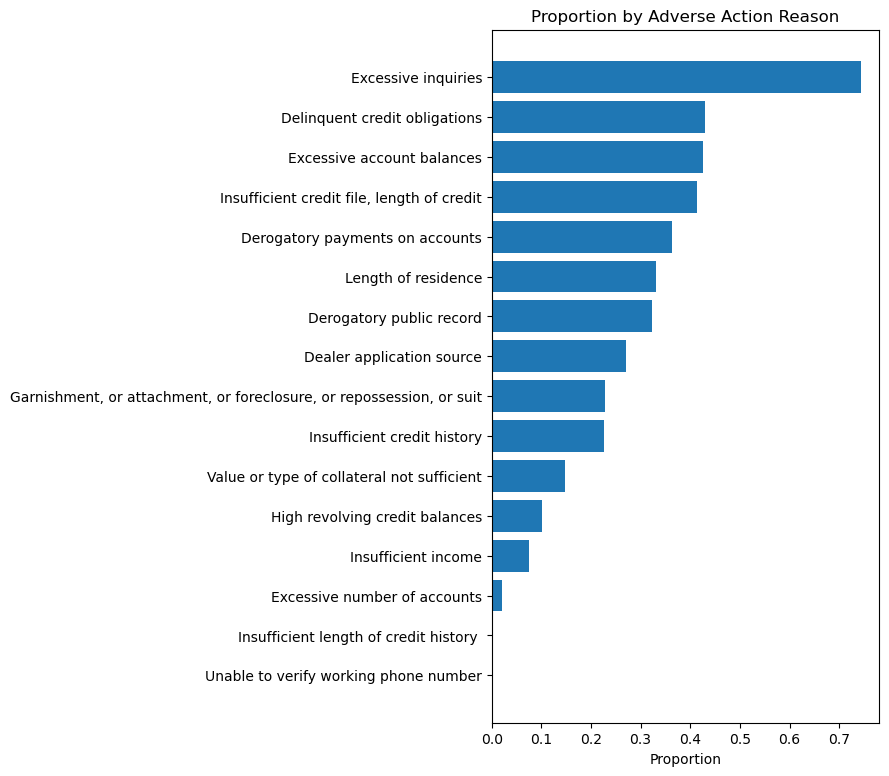

In [25]:
# plot
df_aa.sort_values(by='rate', ascending=True, inplace=True)
fig, ax = plt.subplots(figsize=(5,9))
ax.set_title('Proportion by Adverse Action Reason')
ax.set_xlabel('Proportion')
ax.barh(df_aa['reason'], df_aa['rate'])

# save
str_filename = 'plt_aa_reasons.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

#### Reorder columns

In [26]:
list_cols_first = [
    'accountid',
    'request_datetime',
    'bitdebtor',
    'best_features',
    'worst_features',
]
list_cols_remaining = [col for col in df.columns if col not in list_cols_first]
list_cols = list_cols_first + list_cols_remaining
list_cols = list(dict.fromkeys(list_cols))
df = df[list_cols].copy()
# show
df

,accountid,request_datetime,bitdebtor,best_features,worst_features,list_pmt_hx_closed__tu_pmthx,list_pmt_hx_open__tu_pmthx,amtfinanced__app,bookvalue__app,flt_payment_open__tu_pmthx,...,linka025__tu_binned,fi36s__tu_binned,linkf098__tu_binned,linka006__tu_binned,inquiryshortterm12month__ln_binned,addrinputsubjectcount__ln_binned,g251c__tu_binned,g095s__tu_binned,s209a__tu_binned,inquirynonshortterm12month__ln_binned
7097,8562896,2025-01-14 04:34:07+00:00,0,"[ENG-loan_to_value, rtl_trd__tu, au20s__tu, g2...","[g095s__tu, fi36s__tu, linka006__tu, addrprevi...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",22064.0,35070.0,807.0,...,-0.049256,-0.096438,-0.007887,-0.096511,0.078594,0.079421,0.088503,-0.104589,-0.018363,0.259869
9164,8506098,2024-12-19 00:13:24+00:00,1,"[ENG-loan_to_value, rtl_trd__tu, in21s__tu, re...","[balmag01__tu, miles_odometer__app, fltgrossmo...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",NaN,596.0,8880.0,NaN,...,0.015521,0.177341,-0.007887,0.226562,0.078594,-0.081502,-0.015657,0.251941,0.120165,-0.141947
2272,8477017,2024-12-11 01:43:35+00:00,0,"[ENG-loan_to_value, in21s__tu, fltgrossmonthly...","[rp01s__tu, balmag01__tu, ENG-wtd_avg, g095s__...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, ...",NaN,35000.0,71986.0,NaN,...,-0.049256,0.177341,-0.007887,0.050981,0.078594,0.076370,0.088503,-0.104589,0.120165,0.259869
2807,8523162,2024-12-27 07:59:56+00:00,1,"[ENG-loan_to_value, rtl_trd__tu, au20s__tu, in...","[inquirybanking12month__ln, g095s__tu, trv01__...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, ...",NaN,35000.0,77827.0,NaN,...,0.015521,0.105962,-0.007887,0.084454,0.078594,-0.025594,-0.015657,-0.104589,-0.018363,-0.141947
840,8488152,2024-12-15 01:09:07+00:00,1,"[ENG-loan_to_value, rtl_trd__tu, au20s__tu, mi...","[g002s__tu, in21s__tu, g095s__tu, trv01__tu, E...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",11299.0,23817.0,273.0,...,0.015521,0.177341,-0.007887,0.226562,0.078594,-0.040712,-0.015657,-0.104589,-0.018363,0.259869
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2633,8507838,2024-12-19 05:43:37+00:00,1,"[fltgrossmonthly__income_sum, rev322__tu, ENG-...","[ENG-loan_to_value, derogseverityindex__ln, g2...","[1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",44178.0,26225.0,393.0,...,-0.049256,-0.068424,-0.007887,-0.096511,-0.283473,-0.081502,-0.015657,-0.104589,-0.018363,-0.141947
10732,8555000,2025-01-10 07:07:36+00:00,1,"[cv15__tu, trv01__tu, sourcenonderogcount12mon...","[ENG-loan_to_value, inquiryshortterm12month__l...",NaN,NaN,13279.0,7925.0,NaN,...,0.015521,-0.096438,-0.007887,-0.096511,-0.283473,-0.081502,-0.015657,-0.104589,-0.018363,-0.141947
7262,8481063,2024-12-12 08:04:48+00:00,1,"[g095s__tu, cv13__tu, ENG-franchise, linkt003_...","[ENG-loan_to_value, g232s__tu, inquiryshortter...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, ...",NaN,16725.0,9014.0,NaN,...,-0.049256,-0.068424,-0.007887,-0.096511,-0.283473,0.076370,-0.015657,0.251941,-0.018363,-0.141947
5942,8556978,2025-01-11 03:49:26+00:00,1,"[g407s__tu, g002s__tu, cv13__tu, sourcenondero...","[ENG-loan_to_value, inquiryshortterm12month__l...",NaN,NaN,14660.0,6250.0,NaN,...,-0.049256,-0.096438,-0.007887,-0.096511,-0.283473,-0.081502,-0.015657,-0.104589,-0.018363,-0.141947


#### Save locally

In [27]:
%%time

str_filename = 'df_predictions.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df.to_csv(str_local_path, index=False)

CPU times: user 1.19 s, sys: 24 ms, total: 1.21 s
Wall time: 1.24 s


#### Get the frequencies

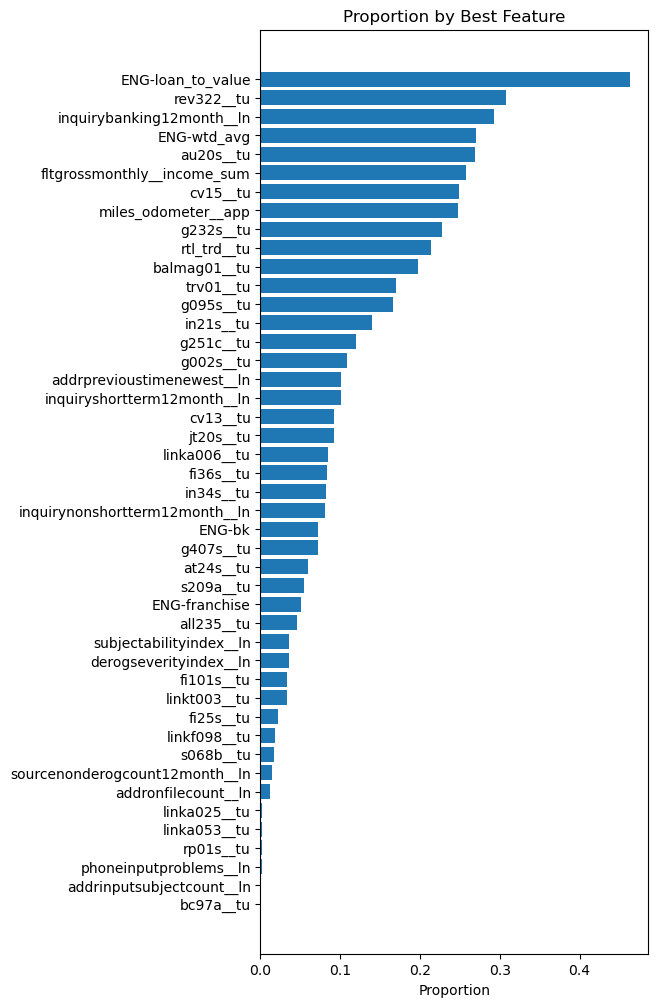

In [28]:
# best
int_nrows = df.shape[0]
ser_feats = pd.Series(chain.from_iterable(df['best_features']))
ser_val_counts = ser_feats.value_counts(normalize=False)
df_freq = ser_val_counts.reset_index()
df_freq.columns = ['feature','frequency']
df_freq['prop'] = df_freq['frequency'] / int_nrows

# save
str_filename = 'df_best_feat_freq.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_freq.to_csv(str_local_path, index=False)

# plot
df_freq.sort_values(by='prop', ascending=True, inplace=True)
fig, ax = plt.subplots(figsize=(5,12))
ax.set_title('Proportion by Best Feature')
ax.set_xlabel('Proportion')
ax.barh(df_freq['feature'], df_freq['prop'])

# save
str_filename = 'plt_best_feat_freq.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

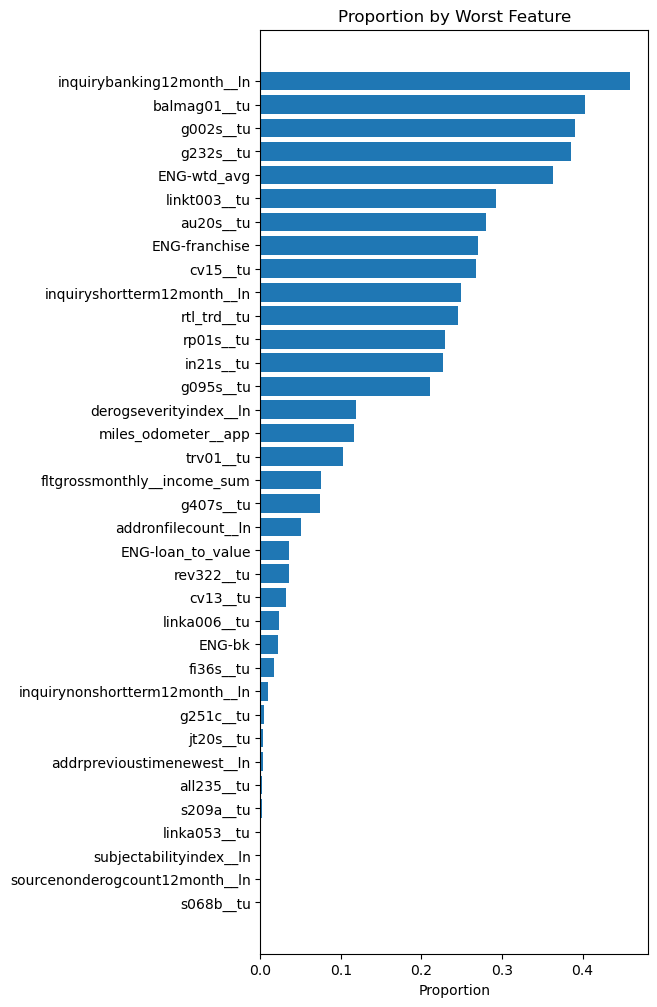

In [29]:
# worst
int_nrows = df.shape[0]
ser_feats = pd.Series(chain.from_iterable(df['worst_features']))
ser_val_counts = ser_feats.value_counts(normalize=False)
df_freq = ser_val_counts.reset_index()
df_freq.columns = ['feature','frequency']
df_freq['prop'] = df_freq['frequency'] / int_nrows

# save
str_filename = 'df_worst_feat_freq.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_freq.to_csv(str_local_path, index=False)

# plot
df_freq.sort_values(by='prop', ascending=True, inplace=True)
fig, ax = plt.subplots(figsize=(5,12))
ax.set_title('Proportion by Worst Feature')
ax.set_xlabel('Proportion')
ax.barh(df_freq['feature'], df_freq['prop'])

# save
str_filename = 'plt_worst_feat_freq.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

#### Random sample

In [30]:
int_random_state = 42
for a in tqdm(range(int_n_samples)):
    df_tmp = df[df['PD'] <= flt_pd_threshold].copy()
    # get sample
    df_tmp = df_tmp.sample(
        n=100,
        random_state=int_random_state,
    )
    df_tmp.sort_values(by='ECNL', ascending=True, inplace=True)

    # save
    str_filename = f'df_predictions_sample_{a+1}.csv'
    str_local_path = f'{str_dirname_output}/{str_filename}'
    df_tmp.to_csv(str_local_path, index=False)
    
    # add
    int_random_state += 1

# show
df_tmp

100%|██████████| 5/5 [00:00<00:00, 60.56it/s]


,accountid,request_datetime,bitdebtor,best_features,worst_features,list_pmt_hx_closed__tu_pmthx,list_pmt_hx_open__tu_pmthx,amtfinanced__app,bookvalue__app,flt_payment_open__tu_pmthx,...,linka025__tu_binned,fi36s__tu_binned,linkf098__tu_binned,linka006__tu_binned,inquiryshortterm12month__ln_binned,addrinputsubjectcount__ln_binned,g251c__tu_binned,g095s__tu_binned,s209a__tu_binned,inquirynonshortterm12month__ln_binned
3487,8541677,2025-01-04 21:20:41+00:00,1,"[rtl_trd__tu, au20s__tu, miles_odometer__app, ...","[ENG-bk, s209a__tu, linka053__tu, s068b__tu, s...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",31091.00,29933.0,284.0,...,0.015521,0.105962,-0.007887,0.084454,0.078594,-0.025594,0.088503,0.251941,-0.018363,0.259869
7941,8470987,2024-12-08 00:47:41+00:00,1,"[ENG-loan_to_value, miles_odometer__app, trv01...","[inquiryshortterm12month__ln, ENG-wtd_avg, au2...",NaN,NaN,58345.00,99095.0,NaN,...,-0.049256,-0.096438,-0.007887,-0.096511,-0.283473,0.076370,0.088503,-0.104589,-0.018363,0.259869
6140,8574483,2025-01-18 02:03:31+00:00,1,"[ENG-loan_to_value, miles_odometer__app, au20s...","[linkt003__tu, g232s__tu, g002s__tu, g407s__tu...","[1, 1]","[1, 1, 1]",13075.73,24099.0,607.0,...,-0.049256,-0.068424,0.129197,-0.096511,0.078594,-0.081502,-0.015657,-0.104589,-0.018363,-0.141947
4099,8464253,2024-12-05 06:51:53+00:00,1,"[ENG-loan_to_value, trv01__tu, rev322__tu, g25...","[linkt003__tu, ENG-wtd_avg, ENG-franchise, au2...",NaN,NaN,17178.09,30475.0,NaN,...,-0.049256,-0.096438,-0.007887,0.084454,0.078594,0.076370,0.088503,-0.104589,-0.018363,0.259869
378,8482217,2024-12-13 01:40:58+00:00,1,"[balmag01__tu, rtl_trd__tu, ENG-loan_to_value,...","[g002s__tu, in21s__tu, g095s__tu, ENG-bk, addr...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",24151.00,26990.0,468.0,...,0.015521,0.177341,-0.007887,0.050981,0.078594,-0.040712,-0.001614,-0.104589,-0.018363,0.259869
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10186,8504906,2024-12-18 04:29:30+00:00,1,"[balmag01__tu, jt20s__tu, g232s__tu, inquirysh...","[inquirybanking12month__ln, g002s__tu, ENG-fra...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, ...",NaN,12080.00,9300.0,NaN,...,0.015521,-0.068424,-0.007887,-0.096511,0.078594,-0.081502,-0.015657,-0.104589,0.002489,-0.141947
3702,8507539,2024-12-19 04:33:47+00:00,1,"[rtl_trd__tu, rev322__tu, in34s__tu, fi25s__tu...","[derogseverityindex__ln, g232s__tu, cv15__tu, ...","[0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, ...",NaN,22156.00,18625.0,NaN,...,-0.049256,-0.068424,-0.007887,-0.096511,0.078594,0.079421,-0.015657,-0.104589,-0.018363,-0.141947
4192,8485481,2024-12-14 02:36:58+00:00,1,"[trv01__tu, ENG-wtd_avg, rev322__tu, au20s__tu...","[cv15__tu, inquirybanking12month__ln, g232s__t...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",25196.00,20125.0,407.0,...,-0.049256,-0.068424,-0.007887,-0.096511,0.078594,0.079421,-0.015657,-0.104589,-0.018363,-0.141947
363,8559499,2025-01-12 02:57:53+00:00,1,"[rev322__tu, fltgrossmonthly__income_sum, inqu...","[g232s__tu, cv15__tu, au20s__tu, miles_odomete...",NaN,"[1, 1, 1, 0]",13774.00,10800.0,599.0,...,-0.049256,-0.096438,-0.007887,-0.096511,0.078594,-0.025594,-0.015657,-0.104589,-0.018363,-0.141947
